In [1]:
#Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import emoji

In [2]:
# Загрузка данных
df = pd.read_excel("../data/vk_posts_raw.xlsx")

df['Текст поста'] = df['Текст поста'].fillna('')
df['Дата публикации'] = pd.to_datetime(df['Дата публикации'])

df.head()

,Post ID,Дата публикации,Просмотры,Лайки,Комментарии,Текст поста
0,41850,2025-08-02 18:10:06,579,27,0,🌍🦂🤔
1,41837,2025-07-30 13:15:16,6022,392,12,Крупная победа 5:1 выводит нас в следующий эта...
2,41830,2025-07-26 20:23:06,3304,207,5,Разгром на Райко Митич!
3,41815,2025-07-24 20:40:54,45793,194,2,Наш новый 89! 🔴⚪️
4,41802,2025-07-22 18:19:14,2883,112,0,Первый матч евросезона закончился скромной поб...


In [3]:
#Признаки
df['Час'] = df['Дата публикации'].dt.hour
df['День_недели'] = df['Дата публикации'].dt.dayofweek
df['Месяц'] = df['Дата публикации'].dt.month
df['Выходной'] = df['День_недели'].apply(lambda x: 1 if x >= 5 else 0)
df['Длина_текста'] = df['Текст поста'].apply(len)

In [4]:
#Эмодзи
def count_emojis(text):
    return sum(1 for char in text if char in emoji.EMOJI_DATA)

df['Кол_эмодзи'] = df['Текст поста'].apply(count_emojis)

#Тональность через TextBlob не считаем: он понимает только английский,
#и для русских текстов polarity всегда равна 0

#Признак "есть медиа или ссылка"
df['Есть_медиа'] = df['Текст поста'].str.contains(r'http|club\d+|photo\d+_\d+|video\d+_\d+|audio\d+_\d+', case=False, regex=True).astype(int)

In [5]:
#Кластеризация
features = ['Час', 'День_недели', 'Длина_текста', 'Кол_эмодзи', 'Есть_медиа']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
df['Кластер'] = kmeans.fit_predict(X_scaled)

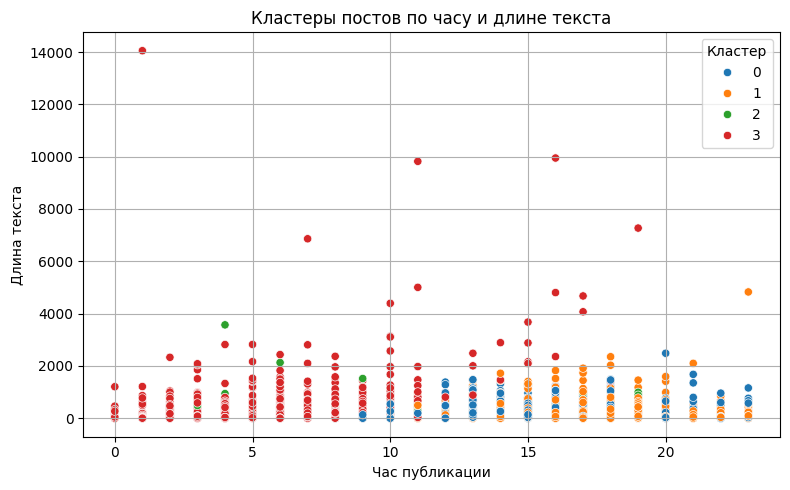

In [6]:
#Визуализация
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Час', y='Длина_текста', hue='Кластер', palette='tab10')
plt.title("Кластеры постов по часу и длине текста")
plt.xlabel("Час публикации")
plt.ylabel("Длина текста")
plt.grid(True)
plt.tight_layout()
plt.show()


def plot_corr_heatmap(corr_matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

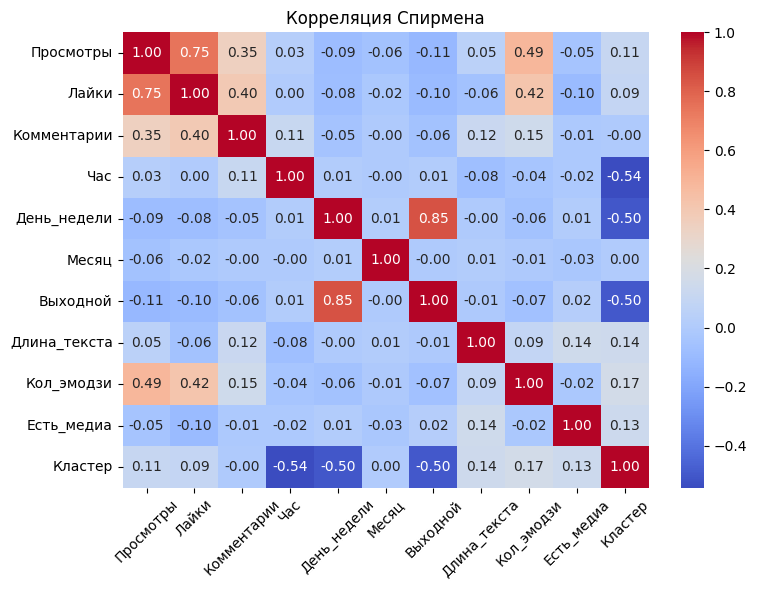

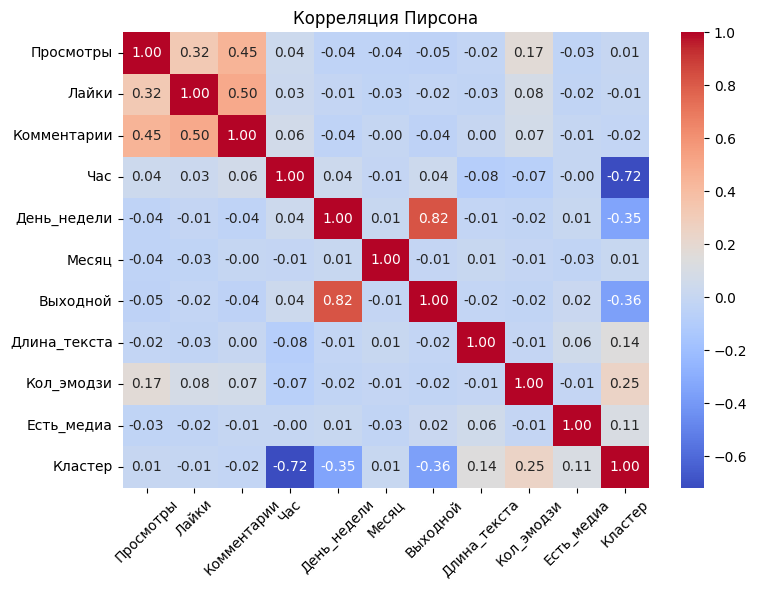

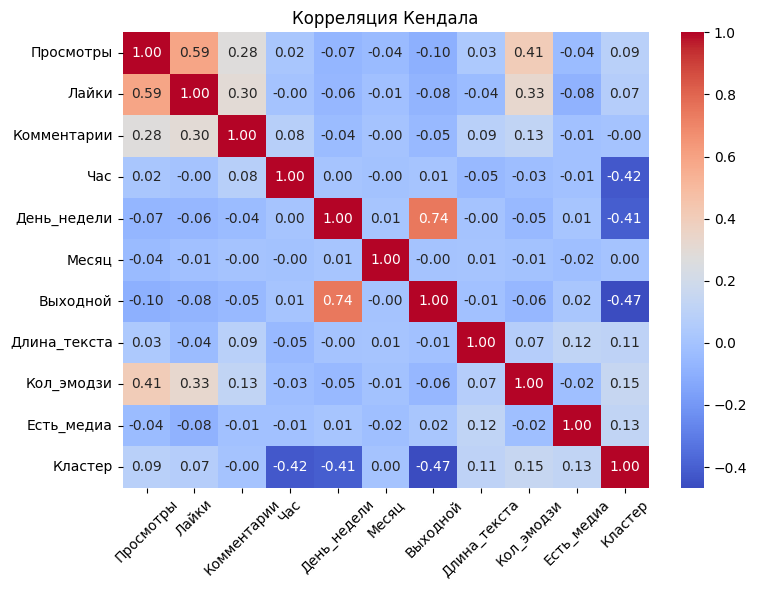

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['Post ID'])

corr_spearman = numeric_cols.corr(method='spearman')
corr_pearson = numeric_cols.corr(method='pearson')
corr_kendall = numeric_cols.corr(method='kendall')

plot_corr_heatmap(corr_spearman, "Корреляция Спирмена")
plot_corr_heatmap(corr_pearson, "Корреляция Пирсона")
plot_corr_heatmap(corr_kendall, "Корреляция Кендала")


Доля объяснённой дисперсии при k=4: 0.4642


Silhouette Score: 0.3049


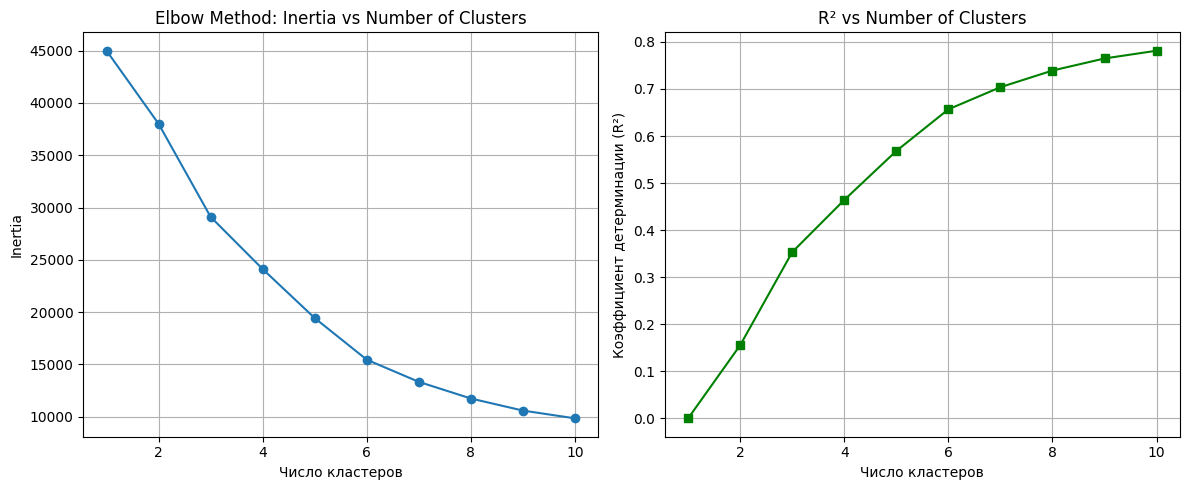

In [8]:
from sklearn.metrics import silhouette_score

#Обучение модели
k = 4
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
df['Кластер'] = kmeans.fit_predict(X_scaled)

#Inertia сумма квадратов расстояний до центров кластеров
inertia = kmeans.inertia_

# Общая дисперсия
total_variance = np.sum(np.var(X_scaled, axis=0)) * X_scaled.shape[0]

#Доля дисперсии, объяснённая разбиением на кластеры (аналог R²)
explained = 1 - inertia / total_variance
print(f"Доля объяснённой дисперсии при k={k}: {explained:.4f}")

#Silhouette score  для оценки компактности/разделимости кластеров
silhouette = silhouette_score(X_scaled, df['Кластер'])
print(f"Silhouette Score: {silhouette:.4f}")

#Elbow Method (график инерции)
inertias = []
r2_scores = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    total_var = np.sum(np.var(X_scaled, axis=0)) * X_scaled.shape[0]
    r2_scores.append(1 - km.inertia_ / total_var)

#Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method: Inertia vs Number of Clusters')
plt.xlabel('Число кластеров')
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), r2_scores, marker='s', color='green')
plt.title('R² vs Number of Clusters')
plt.xlabel('Число кластеров')
plt.ylabel('Коэффициент детерминации (R²)')
plt.grid(True)

plt.tight_layout()
plt.show()